In [1]:
import os
import sys
import random
import bentoml
import numpy as np
import pandas as pd
import pprint as pp
from pathlib import Path

# 현재 노트북이 있는 경로 기준으로 프로젝트 루트(recsys) 경로 계산
current_dir = (
    os.path.dirname(os.path.abspath(__file__))
    if "__file__" in globals()
    else os.getcwd()
)
project_root = os.path.abspath(os.path.join(current_dir, ".."))

# recsys 폴더를 sys.path에 추가
if project_root not in sys.path:
    sys.path.append(project_root)

from setup_env import setup_env

root_dir = setup_env()

from models.transformer.preprocess import SequenceGenerator
from utils.dataset.config import DatasetPath
from utils.dataset.plot import show_items
from models.transformer.model import Model
from utils.retriever.ann import build_index, search

device = "cpu"

[INFO] Font applied: NanumGothic


# Load Dataset

In [2]:
# 데이터셋 경로
dataset_dir = Path(root_dir).joinpath("data/dataset")
paths = DatasetPath(root_dir=dataset_dir, dataset_name="fashion")

df_item = pd.read_parquet(paths.item_metadata_path)
df_user_logs = pd.read_parquet(paths.user_logs_path)
df_user_logs.head()

,user_id,item_id,timestamp,action,age,gender,name,brand_name,price,discount_price,...,base_color,season,year,usage,master_category,sub_category,article_type,fit,occasion,description
0,1,2676,2025-10-21 03:01:00,click,46,Women,Baggit Women Fighter Mayur Black Belt,Baggit,525.0,525.0,...,Black,Summer,2012,Casual,Accessories,Belts,Belts,<UNK>,<UNK>,<p>A belt is an essential detail to complete y...
1,1,2619,2025-10-21 03:02:00,click,46,Women,Baggit Women Blue Spirit Dum Belt,Baggit,575.0,575.0,...,Blue,Summer,2012,Casual,Accessories,Belts,Belts,<UNK>,<UNK>,<p><strong>Style Note </strong><br />A summer ...
2,1,1617,2025-10-21 03:05:00,click,46,Women,Baggit Women Flora Moly Red Belt,Baggit,500.0,500.0,...,Red,Summer,2012,Casual,Accessories,Belts,Belts,<UNK>,<UNK>,<p><strong>Style Note</strong><br /> A belt is...
3,1,8224,2025-10-21 03:04:00,click,46,Women,Baggit Women Brown Xylo Taj Belt,Baggit,575.0,575.0,...,Brown,Summer,2012,Casual,Accessories,Belts,Belts,<UNK>,<UNK>,<p><strong>Style Note </strong><br />A summer ...
4,1,1114,2025-10-21 03:17:00,click,46,Women,Wills Lifestyle Women Leather Blue Belt,Wills Lifestyle,999.0,649.0,...,Blue,Summer,2012,Casual,Accessories,Belts,Belts,<UNK>,<UNK>,"<div><span style=""font-family: tahoma, arial, ..."


# Load Model

In [3]:
# 모델 저장 디렉토리 경로
seq_model_artifact = bentoml.models.get("transformer:latest")
reg_model_artifact = bentoml.models.get("regressor:latest")

seq_model_dir = Path(seq_model_artifact.path_of("artifact"))
reg_model_dir = Path(reg_model_artifact.path_of("artifact"))

# 모델 객체 초기화
model = Model(seq_model_dir=seq_model_dir, reg_model_dir=reg_model_dir)

## Prediction Test

In [4]:
# 학습 데이터셋의 랜덤 유저를 추출하여 시퀀스 샘플 생성
user_id = random.choice(df_user_logs["user_id"].unique())
df_user_sample = df_user_logs[df_user_logs["user_id"] == user_id]
df_user_sample = df_user_sample.sort_values(by="user_id", ignore_index=True)

In [5]:
sequence_generator = SequenceGenerator(max_seq_len=model.seq_model_config["seq_len"])

feature_names = list(model.seq_model_config["feature_dims"].keys()) + ["item_id"]
target_names = list(model.seq_model_config["feature_dims"].keys())

df_seq_sample = sequence_generator.get_seq_dataframe(
    data=df_user_sample, feature_sequences=feature_names
)
df_seq_sample = df_seq_sample[df_seq_sample["seq_len"] == 5]
df_seq_sample

,user_id,user_rn,seq_len,mask,brand_name,gender,age_group,base_color,season,year,usage,master_category,sub_category,article_type,fit,occasion,action,item_id,y_item_id
3,4043,4,5,"[0, 0, 0, 0, 0]","[Q&Q, Timex, Timex, Q&Q, Lucera]","[Men, Men, Men, Men, Women]","[Adults-Men, Adults-Men, Adults-Men, Adults-Me...","[Black, Black, Steel, Blue, Silver]","[Winter, Winter, Winter, Winter, Summer]","[2016, 2016, 2016, 2016, 2013]","[Casual, Casual, Casual, Casual, Casual]","[Accessories, Accessories, Accessories, Access...","[Watches, Watches, Watches, Watches, Jewellery]","[Watches, Watches, Watches, Watches, Earrings]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, <UNK>, <UNK>, <UNK>, Western]","[click, click, purchase, click, cart]","[8288, 6672, 2856, 5948, 2545]","[6672, 2856, 5948, 2545, 8530]"
5,4043,7,5,"[0, 0, 0, 0, 0]","[Elle, Sepia, French Connection, Arrow Woman, ...","[Women, Women, Women, Women, Women]","[Adults-Women, Adults-Women, Adults-Women, Adu...","[White, Green, Navy Blue, Red, Green]","[Summer, Summer, Summer, Summer, Summer]","[2012, 2012, 2012, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Apparel, Apparel, Apparel, Apparel, Apparel]","[Topwear, Topwear, Topwear, Topwear, Topwear]","[Tops, Tops, Tops, Tops, Tops]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[Casual, Casual, Casual, Casual, <UNK>]","[click, cart, click, click, click]","[5822, 2465, 1727, 8211, 4875]","[2465, 1727, 8211, 4875, 3820]"
6,4043,8,5,"[0, 0, 0, 0, 0]","[Arrow Woman, Elle, Sepia, French Connection, ...","[Women, Women, Women, Women, Women]","[Adults-Women, Adults-Women, Adults-Women, Adu...","[Teal, White, Green, Navy Blue, Red]","[Summer, Summer, Summer, Summer, Summer]","[2012, 2012, 2012, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Apparel, Apparel, Apparel, Apparel, Apparel]","[Topwear, Topwear, Topwear, Topwear, Topwear]","[Tops, Tops, Tops, Tops, Tops]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[Casual, Casual, Casual, Casual, Casual]","[click, click, cart, click, click]","[111, 5822, 2465, 1727, 8211]","[5822, 2465, 1727, 8211, 4875]"
7,4043,9,5,"[0, 0, 0, 0, 0]","[Latin Quarters, Arrow Woman, Elle, Sepia, Fre...","[Women, Women, Women, Women, Women]","[Adults-Women, Adults-Women, Adults-Women, Adu...","[Red, Teal, White, Green, Navy Blue]","[Summer, Summer, Summer, Summer, Summer]","[2012, 2012, 2012, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Apparel, Apparel, Apparel, Apparel, Apparel]","[Topwear, Topwear, Topwear, Topwear, Topwear]","[Tops, Tops, Tops, Tops, Tops]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[Casual, Casual, Casual, Casual, Casual]","[click, click, click, cart, click]","[1677, 111, 5822, 2465, 1727]","[111, 5822, 2465, 1727, 8211]"
8,4043,10,5,"[0, 0, 0, 0, 0]","[Arrow Woman, Latin Quarters, Arrow Woman, Ell...","[Women, Women, Women, Women, Women]","[Adults-Women, Adults-Women, Adults-Women, Adu...","[Black, Red, Teal, White, Green]","[Summer, Summer, Summer, Summer, Summer]","[2012, 2012, 2012, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Apparel, Apparel, Apparel, Apparel, Apparel]","[Topwear, Topwear, Topwear, Topwear, Topwear]","[Tops, Tops, Tops, Tops, Tops]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[Casual, Casual, Casual, Casual, Casual]","[click, click, click, click, cart]","[6360, 1677, 111, 5822, 2465]","[1677, 111, 5822, 2465, 1727]"
9,4043,11,5,"[0, 0, 0, 0, 0]","[Sepia, ONLY, Jealous 21, Q&Q, Q&Q]","[Women, Women, Women, Men, Men]","[Adults-Women, Adults-Women, Adults-Women, Adu...","[Blue, Black, Pink, Black, Black]","[Summer, Summer, Summer, Winter, Winter]","[2012, 2012, 2012, 2016, 2016]","[Casual, Casual, Casual, Casual, Casual]","[Apparel, Apparel, Apparel, Accessories, Acces...","[Topwear, Topwear, Topwear, Watches, Watches]","[Tops, Tops, Tops, Watches, Watches]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[Casual, Casual, Casual, Casual, <UNK>]","[click, click, click, click, click]","[4720, 3797, 365, 4643, 8288]","[3797, 365, 4643, 8288, 6672]"
10,40

In [6]:
seq_sample = df_seq_sample.sample(1).to_dict(orient="records")[0]
seq_sample

{'user_id': 4043,
 'user_rn': 10,
 'seq_len': 5,
 'mask': [0, 0, 0, 0, 0],
 'brand_name': ['Arrow Woman',
  'Latin Quarters',
  'Arrow Woman',
  'Elle',
  'Sepia'],
 'gender': ['Women', 'Women', 'Women', 'Women', 'Women'],
 'age_group': ['Adults-Women',
  'Adults-Women',
  'Adults-Women',
  'Adults-Women',
  'Adults-Women'],
 'base_color': ['Black', 'Red', 'Teal', 'White', 'Green'],
 'season': ['Summer', 'Summer', 'Summer', 'Summer', 'Summer'],
 'year': ['2012', '2012', '2012', '2012', '2012'],
 'usage': ['Casual', 'Casual', 'Casual', 'Casual', 'Casual'],
 'master_category': ['Apparel', 'Apparel', 'Apparel', 'Apparel', 'Apparel'],
 'sub_category': ['Topwear', 'Topwear', 'Topwear', 'Topwear', 'Topwear'],
 'article_type': ['Tops', 'Tops', 'Tops', 'Tops', 'Tops'],
 'fit': ['<UNK>', '<UNK>', '<UNK>', '<UNK>', '<UNK>'],
 'occasion': ['Casual', 'Casual', 'Casual', 'Casual', 'Casual'],
 'action': ['click', 'click', 'click', 'click', 'cart'],
 'item_id': [6360, 1677, 111, 5822, 2465],
 'y_item

In [7]:
inputs = {}
for k in model.seq_model_config["feature_dims"].keys():
    inputs[k] = seq_sample[k]

pp.pprint(inputs)

{'action': ['click', 'click', 'click', 'click', 'cart'],
 'age_group': ['Adults-Women',
               'Adults-Women',
               'Adults-Women',
               'Adults-Women',
               'Adults-Women'],
 'article_type': ['Tops', 'Tops', 'Tops', 'Tops', 'Tops'],
 'base_color': ['Black', 'Red', 'Teal', 'White', 'Green'],
 'brand_name': ['Arrow Woman',
                'Latin Quarters',
                'Arrow Woman',
                'Elle',
                'Sepia'],
 'fit': ['<UNK>', '<UNK>', '<UNK>', '<UNK>', '<UNK>'],
 'gender': ['Women', 'Women', 'Women', 'Women', 'Women'],
 'master_category': ['Apparel', 'Apparel', 'Apparel', 'Apparel', 'Apparel'],
 'occasion': ['Casual', 'Casual', 'Casual', 'Casual', 'Casual'],
 'season': ['Summer', 'Summer', 'Summer', 'Summer', 'Summer'],
 'sub_category': ['Topwear', 'Topwear', 'Topwear', 'Topwear', 'Topwear'],
 'usage': ['Casual', 'Casual', 'Casual', 'Casual', 'Casual'],
 'year': ['2012', '2012', '2012', '2012', '2012']}


In [8]:
# 예시 입력: user_id와 시퀀스
body = [{"user_id": 123, "inputs": inputs}]

# Model.predict 호출 -> Transformer + Projection 결과 생성
prediction = model.predict(body)[0]
# pp.pprint(prediction)
# 출력: {"outputs": feature별 예측 값, "seq_vector": [...], "item_vector": [...]}

/Users/hwangyungwan/miniforge3/envs/ds_p313/lib/python3.13/site-packages/torch/nn/modules/transformer.py:505: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


# Recommendation

In [9]:
# 이미지 기반 아이템 벡터 로드
df_image_vectors = pd.read_parquet(paths.image_vectors_path)

# text_vectors: (num_items, dim) numpy float32 배열
image_vectors = np.array(df_image_vectors["image_vector"].tolist())
image_vectors = np.array(image_vectors).astype(np.float32)

# {item index: item_id} 매핑
# (`df_text_vectors.index는` row index이므로 range(0..N-1)로 반환함)
item_id_maps = dict(zip(df_image_vectors["item_id"].index, df_image_vectors["item_id"]))

In [10]:
# 아이템 벡터 ANN 인덱스 생성
item_index = build_index(image_vectors)

In [11]:
# projection 모델에서 뽑은 item vector
query_vector = np.array(prediction["item_vector"])

# 아이템 벡터 인덱스에 질의한 결과 획득
result = search(query_vector, item_index, top_k=30)

# 추천 아이템 Index (원본 ID가 아닌 별도의 인덱스)
item_indies = list(result.keys())

# 추천 아이템 ID 재매핑
recommendation = {}
for i in item_indies:
    # 원본 ID로 매핑
    item_id = item_id_maps[i]
    recommendation[item_id] = result[i]

recommendation

{1103: 0.9546106457710266,
 656: 0.9538052082061768,
 5303: 0.9533124566078186,
 8001: 0.951179563999176,
 506: 0.9500501155853271,
 1576: 0.9495750069618225,
 2528: 0.9482105374336243,
 7634: 0.9479533433914185,
 7312: 0.9472805261611938,
 4567: 0.9471196532249451,
 5730: 0.9467087984085083,
 5988: 0.9464184045791626,
 5594: 0.946323573589325,
 816: 0.9461576342582703,
 630: 0.9455419778823853,
 3365: 0.9454343318939209,
 8598: 0.9450229406356812,
 4793: 0.9448526501655579,
 8211: 0.9447380304336548,
 70: 0.9445529580116272,
 5211: 0.9445334076881409,
 23: 0.9441788792610168,
 9320: 0.9441286325454712,
 2160: 0.9431331753730774,
 4956: 0.9429953694343567,
 6861: 0.9427029490470886,
 4709: 0.9426603317260742,
 3675: 0.9424770474433899,
 759: 0.9424513578414917,
 4438: 0.9417830109596252}

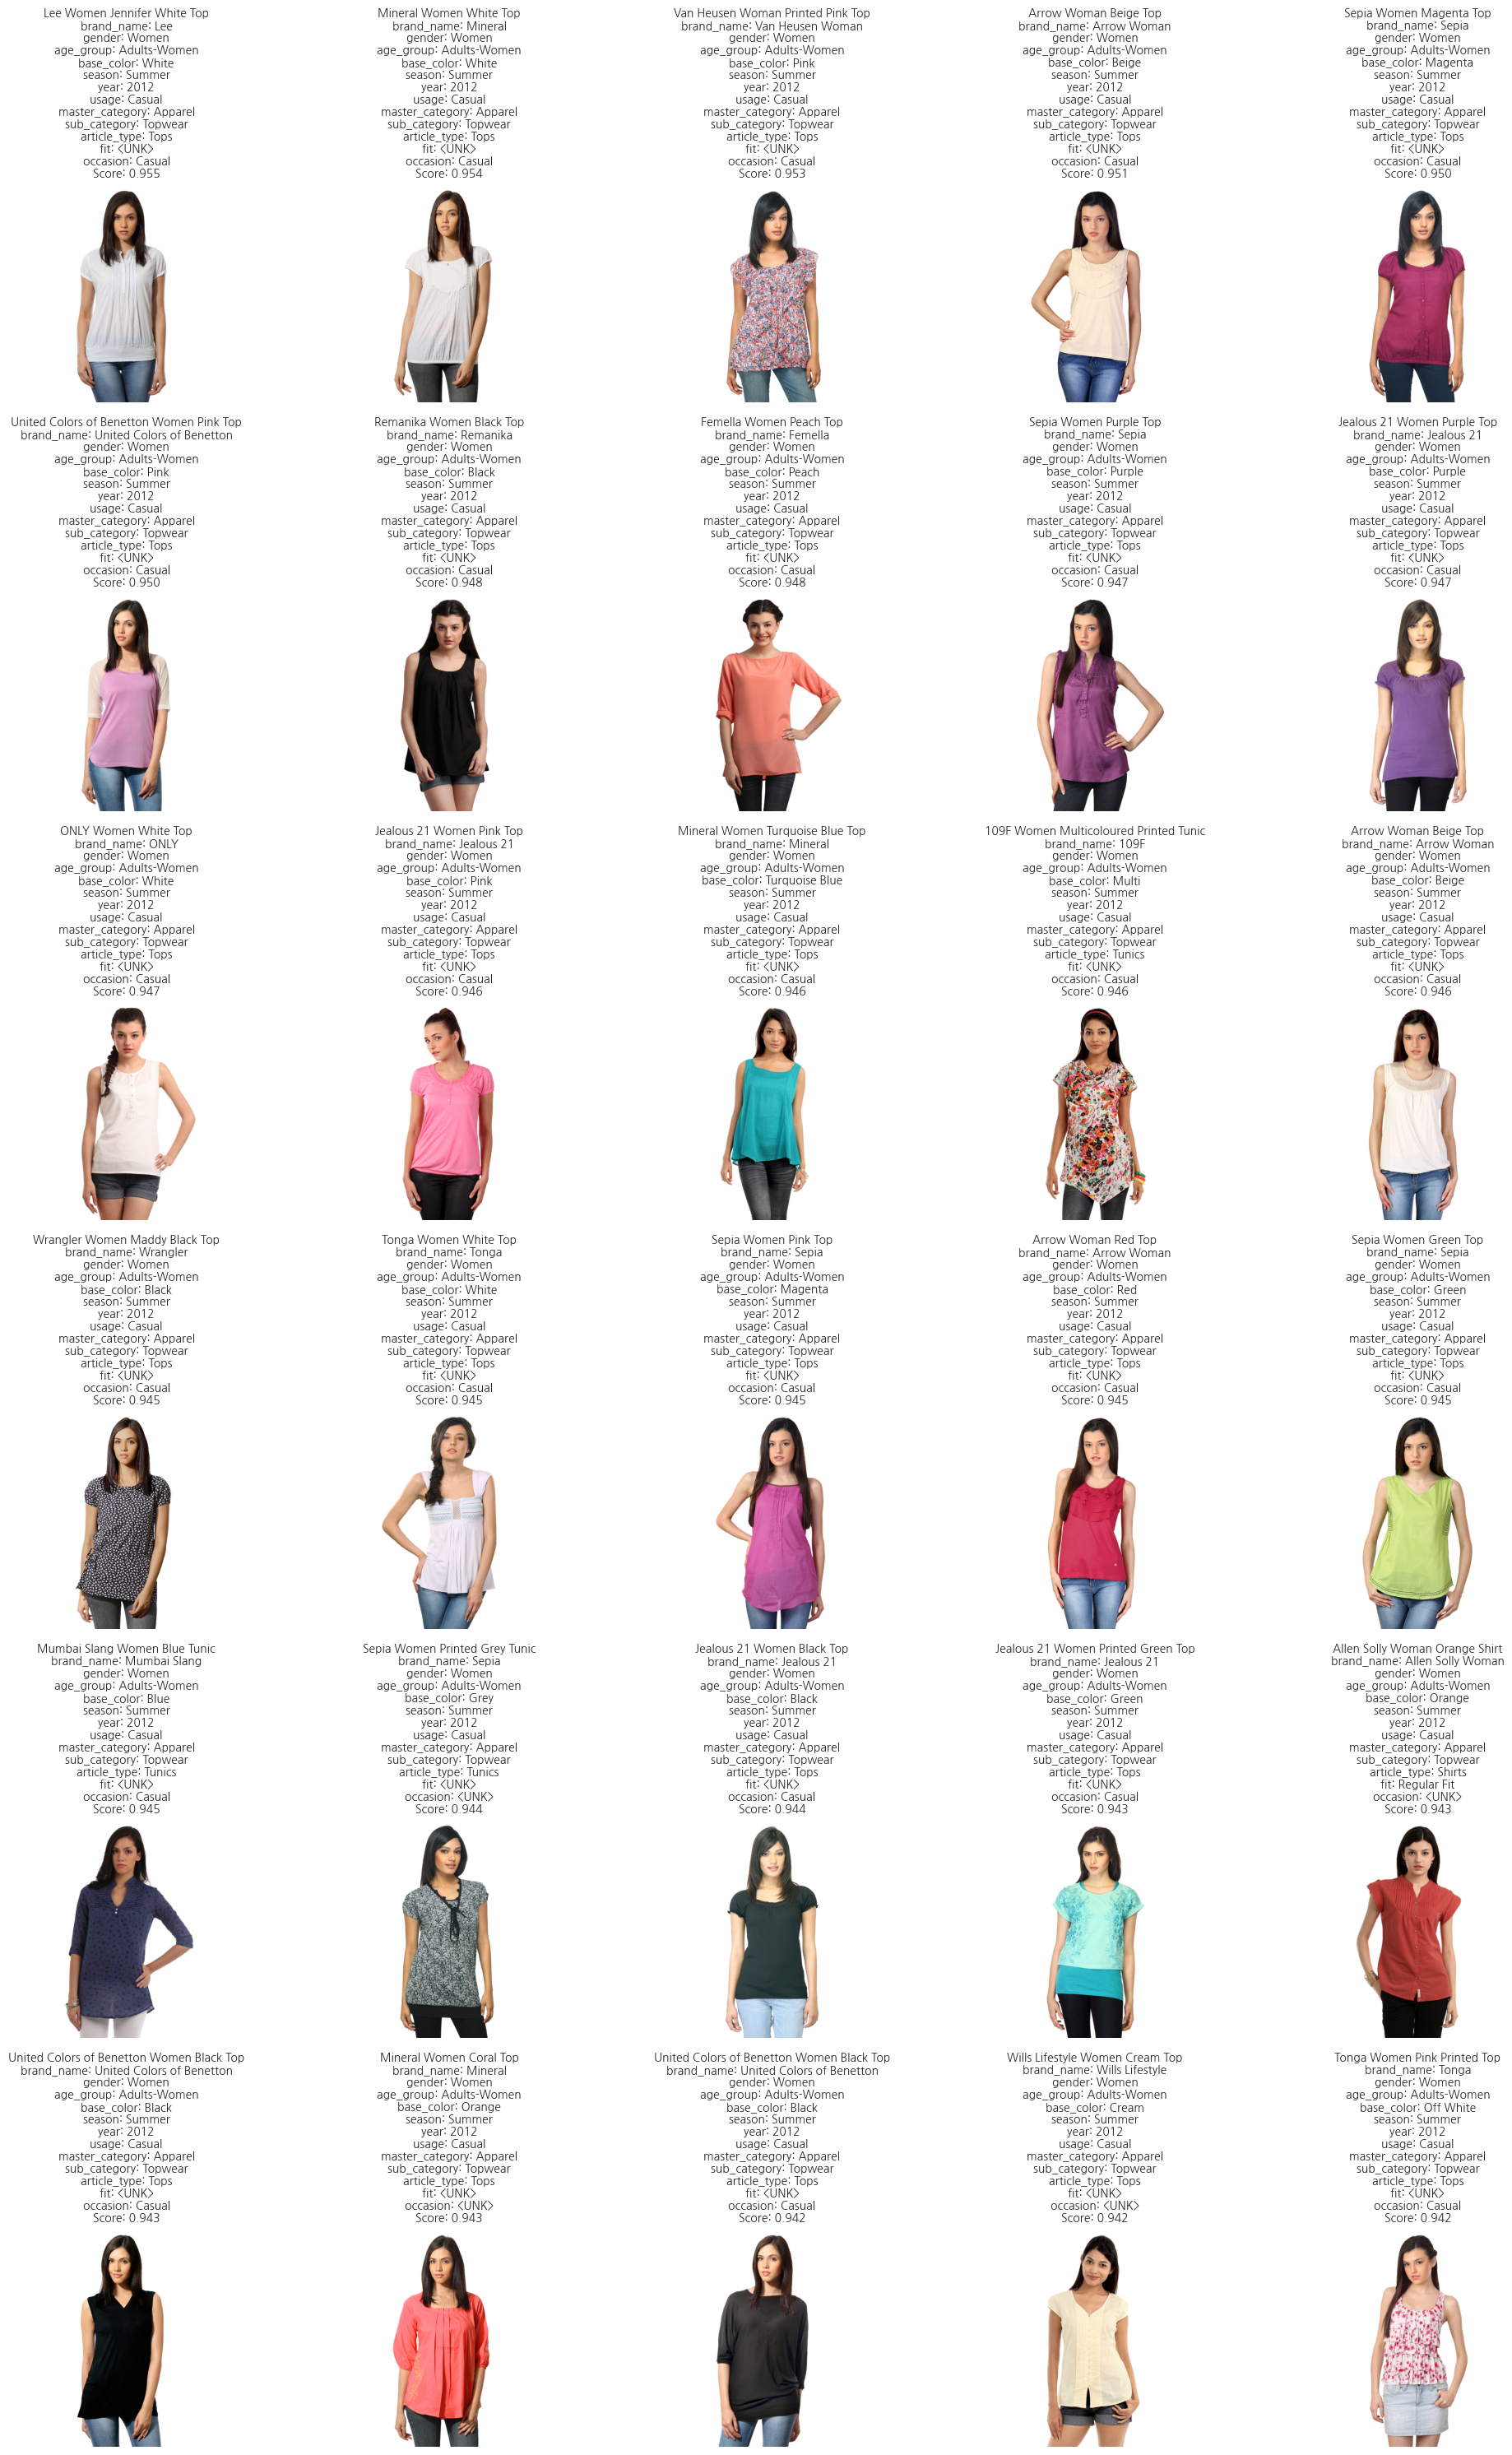

In [12]:
# 추천 아이템 후보군 상세 보기
show_items(
    item_ids=list(recommendation.keys()),
    df_item=df_item,
    attributes=tuple(model.seq_model_config["feature_dims"].keys()),
    scores=list(recommendation.values()),
    image_dir=paths.dataset_dir.joinpath("images"),
)